# Switching predictive model performance

Notebook pour analyser les modeles switching predictifs:

- performance globale LOSO;
- performance par user/fold;
- matrice de confusion;
- predictions correctes vs incorrectes;
- erreurs les plus confiantes;
- erreurs de regression sur les facteurs NASA-TLX;
- section optionnelle pour charger le modele final unique.

Les checkpoints LOSO `fold_<user>/best.pt` servent a evaluer la generalisation. Le modele final unique est `outputs/switching_predictive/final/best.pt`.

## 1. Setup

Cette partie ne charge pas PyTorch. Elle lit les fichiers JSON/CSV deja produits par l'evaluation.

In [1]:
from pathlib import Path
import json
import math
import sys

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


def find_project_root(start: Path) -> Path:
    start = start.resolve()
    for candidate in [start, *start.parents]:
        if (candidate / "fusion_model.py").is_file():
            return candidate
    raise RuntimeError("Could not find project root containing fusion_model.py")


ROOT = find_project_root(Path.cwd())
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

RESULT_DIR = ROOT / "outputs" / "switching_predictive"
DATA_DIR = ROOT / "data_training"
LOS0_JSON = RESULT_DIR / "loso_results.json"
LOSO_CSV = RESULT_DIR / "loso_summary.csv"
FINAL_CKPT = RESULT_DIR / "final" / "best.pt"
METADATA_PATH = DATA_DIR / "metadata.json"

STATE_NAMES = ["Flow", "Neutral", "Bored", "Distracted", "Overloaded"]
FACTOR_NAMES = ["mental_demand", "temporal_demand", "effort", "frustration", "arousal_proxy"]

print("ROOT:", ROOT)
print("LOSO json exists:", LOS0_JSON.exists(), LOS0_JSON)
print("LOSO csv exists:", LOSO_CSV.exists(), LOSO_CSV)
print("Final checkpoint exists:", FINAL_CKPT.exists(), FINAL_CKPT)
print("Metadata exists:", METADATA_PATH.exists(), METADATA_PATH)

ROOT: C:\Users\medte\OneDrive\Desktop\Fusion_Model
LOSO json exists: True C:\Users\medte\OneDrive\Desktop\Fusion_Model\outputs\switching_predictive\loso_results.json
LOSO csv exists: True C:\Users\medte\OneDrive\Desktop\Fusion_Model\outputs\switching_predictive\loso_summary.csv
Final checkpoint exists: True C:\Users\medte\OneDrive\Desktop\Fusion_Model\outputs\switching_predictive\final\best.pt
Metadata exists: True C:\Users\medte\OneDrive\Desktop\Fusion_Model\data_training\metadata.json


## 2. Load LOSO results

In [2]:
with LOS0_JSON.open("r", encoding="utf-8") as handle:
    loso = json.load(handle)

fold_df = pd.read_csv(LOSO_CSV)

overall = {
    "num_folds": loso["num_folds"],
    "num_samples": loso["num_samples"],
    "factor_mae": loso["factor_mae"],
    "factor_rmse": loso["factor_rmse"],
    "state_accuracy": loso["state_accuracy"],
    "macro_f1": loso["macro_f1"],
    "mcc": loso["mcc"],
    "cohen_kappa": loso["cohen_kappa"],
}
display(pd.DataFrame([overall]))

per_class = pd.DataFrame({
    "state": STATE_NAMES,
    "f1": loso["per_class_f1"],
})
display(per_class)

,num_folds,num_samples,factor_mae,factor_rmse,state_accuracy,macro_f1,mcc,cohen_kappa
0,10,371,0.199803,0.268549,0.210243,0.069488,-0.299596,-0.182531


,state,f1
0,Flow,0.000000
1,Neutral,0.347439
2,Bored,0.000000
3,Distracted,0.000000
4,Overloaded,0.000000


## 3. Confusion matrix

Lignes = vraie classe. Colonnes = prediction.

,pred_Flow,pred_Neutral,pred_Bored,pred_Distracted,pred_Overloaded
true_Flow,0,39,0,0,0
true_Neutral,0,78,0,47,0
true_Bored,0,65,0,0,0
true_Distracted,0,111,0,0,0
true_Overloaded,0,31,0,0,0


,Flow,Neutral,Bored,Distracted,Overloaded
Flow,0.00,1.00,0.00,0.00,0.00
Neutral,0.00,0.62,0.00,0.38,0.00
Bored,0.00,1.00,0.00,0.00,0.00
Distracted,0.00,1.00,0.00,0.00,0.00
Overloaded,0.00,1.00,0.00,0.00,0.00


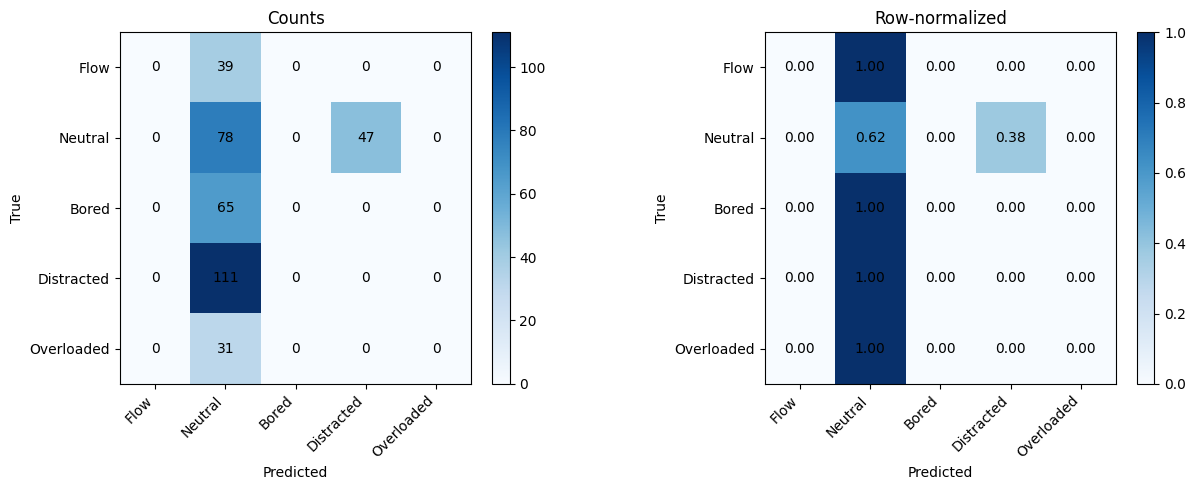

In [3]:
cm = np.asarray(loso["confusion_matrix"], dtype=int)
cm_df = pd.DataFrame(cm, index=[f"true_{s}" for s in STATE_NAMES], columns=[f"pred_{s}" for s in STATE_NAMES])
display(cm_df)

row_sums = cm.sum(axis=1, keepdims=True)
cm_norm = np.divide(cm, row_sums, out=np.zeros_like(cm, dtype=float), where=row_sums != 0)
cm_norm_df = pd.DataFrame(cm_norm, index=STATE_NAMES, columns=STATE_NAMES)
display(cm_norm_df.style.format("{:.2f}"))

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
for ax, mat, title in [(axes[0], cm, "Counts"), (axes[1], cm_norm, "Row-normalized")]:
    im = ax.imshow(mat, cmap="Blues")
    ax.set_title(title)
    ax.set_xlabel("Predicted")
    ax.set_ylabel("True")
    ax.set_xticks(range(5))
    ax.set_yticks(range(5))
    ax.set_xticklabels(STATE_NAMES, rotation=45, ha="right")
    ax.set_yticklabels(STATE_NAMES)
    for i in range(5):
        for j in range(5):
            text = f"{mat[i, j]:.2f}" if mat.dtype.kind == "f" else str(int(mat[i, j]))
            ax.text(j, i, text, ha="center", va="center", color="black")
    fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
plt.tight_layout()
plt.show()

## 4. Performance by user/fold

,test_user,num_samples,factor_mae,factor_rmse,state_accuracy,macro_f1,mcc,cohen_kappa,state_mode,task,class_weight_mode,state_loss,checkpoint
9,mohanned,16,0.461721,0.465105,1.00000,0.200000,0.0,0.0,5class,joint,none,ce,outputs\switching_predictive\fold_mohanned\bes...
7,layss,64,0.220657,0.373523,0.40625,0.115556,0.0,0.0,5class,joint,none,ce,outputs\switching_predictive\fold_layss\best.pt
1,dem,161,0.134559,0.158108,0.21118,0.069744,0.0,0.0,5class,joint,none,ce,outputs\switching_predictive\fold_dem\best.pt
4,hffz,41,0.300586,0.316238,0.04878,0.018605,0.0,0.0,5class,joint,none,ce,outputs\switching_predictive\fold_hffz\best.pt
0,amrdroid,16,0.177339,0.221536,0.00000,0.000000,0.0,0.0,5class,joint,none,ce,outputs\switching_predictive\fold_amrdroid\bes...
2,ghoss,15,0.218621,0.274587,0.00000,0.000000,0.0,0.0,5class,joint,none,ce,outputs\switching_predictive\fold_ghoss\best.pt
3,Graja,11,0.239358,0.278042,0.00000,0.000000,0.0,0.0,5class,joint,none,ce,outputs\switching_predictive\fold_Graja\best.pt
5,ignorant,16,0.059561,0.070276,0.00000,0.000000,0.0,0.0,5class,joint,none,ce,outputs\switching_predictive\fold_ignorant\bes...
6,ladabos,16,0.218170,0.262594,0.00000,0.000000,0.0,0.0,5class,joint,none,ce,outputs\switching_predictive\fold_ladabos\best.pt
8,Makki,15,0.362409,0.390873,0.00000,0.000000,0.0,0.0,5class,joint,none,ce,outputs\switching_predictive\fold_Makki\best.pt


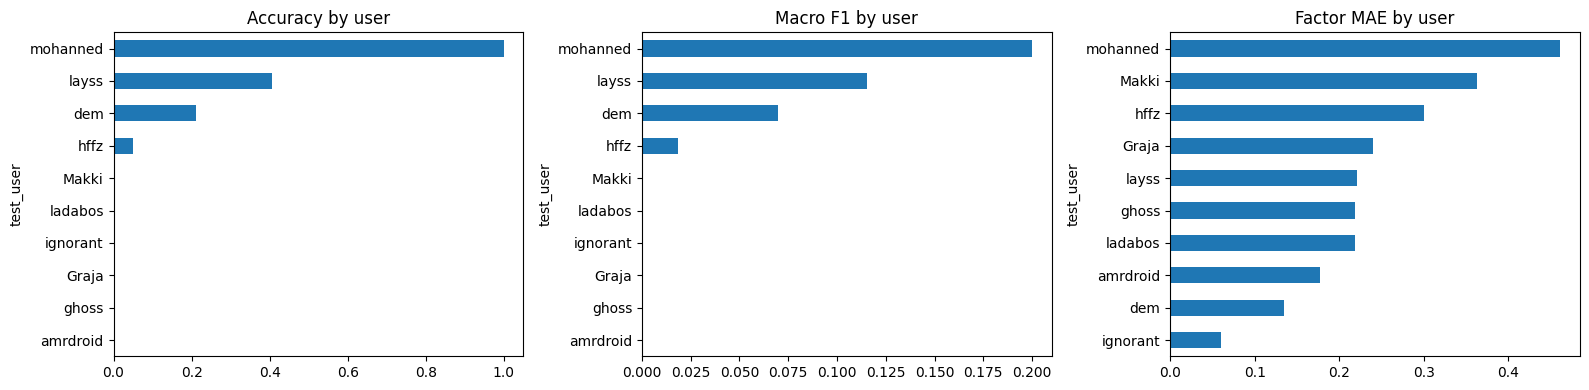

In [4]:
display(fold_df.sort_values("state_accuracy", ascending=False))

fig, axes = plt.subplots(1, 3, figsize=(16, 4))
fold_df.sort_values("state_accuracy").plot.barh(x="test_user", y="state_accuracy", ax=axes[0], legend=False, title="Accuracy by user")
fold_df.sort_values("macro_f1").plot.barh(x="test_user", y="macro_f1", ax=axes[1], legend=False, title="Macro F1 by user")
fold_df.sort_values("factor_mae").plot.barh(x="test_user", y="factor_mae", ax=axes[2], legend=False, title="Factor MAE by user")
plt.tight_layout()
plt.show()

## 5. Build prediction table

Chaque ligne correspond a une fenetre test LOSO. `correct=True` signifie que la classe predite egale la classe heuristique cible.

In [5]:
metadata = json.loads(METADATA_PATH.read_text(encoding="utf-8"))
metadata_by_user = {}
for row in metadata:
    metadata_by_user.setdefault(str(row.get("user_id")), []).append(row)


def softmax_np(logits):
    logits = np.asarray(logits, dtype=float)
    z = logits - np.max(logits)
    exp = np.exp(z)
    return exp / exp.sum()


records = []
for fold in loso["folds"]:
    user = str(fold["test_user"])
    metas = metadata_by_user.get(user, [])
    n = len(fold["y_true"])
    if len(metas) != n:
        print(f"warning: metadata count mismatch for {user}: metadata={len(metas)} predictions={n}")
    for i in range(n):
        meta = metas[i] if i < len(metas) else {}
        logits = np.asarray(fold["logits"][i], dtype=float)
        probs = softmax_np(logits)
        top2 = np.sort(probs)[-2:]
        y_true = int(fold["y_true"][i])
        y_pred = int(fold["y_pred"][i])
        factor_target = np.asarray(fold["factor_targets"][i], dtype=float)
        factor_pred = np.asarray(fold["factor_preds"][i], dtype=float)
        rec = {
            "user_id": user,
            "session_id": meta.get("session_id"),
            "window_idx": meta.get("window_idx"),
            "window_start": meta.get("window_start"),
            "window_end": meta.get("window_end"),
            "true_label": y_true,
            "pred_label": y_pred,
            "true_state": STATE_NAMES[y_true],
            "pred_state": STATE_NAMES[y_pred],
            "correct": y_true == y_pred,
            "confidence": float(np.max(probs)),
            "margin": float(top2[-1] - top2[-2]) if len(top2) == 2 else 0.0,
            "factor_mae": float(np.mean(np.abs(factor_pred - factor_target))),
        }
        for j, state in enumerate(STATE_NAMES):
            rec[f"prob_{state}"] = float(probs[j])
            rec[f"logit_{state}"] = float(logits[j])
        for j, factor in enumerate(FACTOR_NAMES):
            rec[f"target_{factor}"] = float(factor_target[j])
            rec[f"pred_{factor}"] = float(factor_pred[j])
            rec[f"abs_err_{factor}"] = float(abs(factor_pred[j] - factor_target[j]))
        records.append(rec)

pred_df = pd.DataFrame(records)
print(pred_df.shape)
display(pred_df.head())

(371, 38)


,user_id,session_id,window_idx,window_start,window_end,true_label,pred_label,true_state,pred_state,correct,...,abs_err_temporal_demand,target_effort,pred_effort,abs_err_effort,target_frustration,pred_frustration,abs_err_frustration,target_arousal_proxy,pred_arousal_proxy,abs_err_arousal_proxy
0,amrdroid,session_20260516_110318_a84820,0,1.778926e+09,1.778926e+09,1,3,Neutral,Distracted,False,...,0.098735,0.45,0.389056,0.060944,0.77,0.361937,0.408063,0.535,0.460805,0.074195
1,amrdroid,session_20260516_110318_a84820,1,1.778926e+09,1.778926e+09,1,3,Neutral,Distracted,False,...,0.098735,0.45,0.389056,0.060944,0.77,0.361937,0.408063,0.535,0.460805,0.074195
2,amrdroid,session_20260516_110318_a84820,2,1.778926e+09,1.778926e+09,1,3,Neutral,Distracted,False,...,0.098735,0.45,0.389056,0.060944,0.77,0.361937,0.408063,0.535,0.460805,0.074195
3,amrdroid,session_20260516_110318_a84820,3,1.778926e+09,1.778926e+09,1,3,Neutral,Distracted,False,...,0.098735,0.45,0.389056,0.060944,0.77,0.361937,0.408063,0.535,0.460805,0.074195
4,amrdroid,session_20260516_110318_a84820,4,1.778926e+09,1.778926e+09,1,3,Neutral,Distracted,False,...,0.098735,0.45,0.389056,0.060944,0.77,0.361937,0.408063,0.535,0.460805,0.074195


## 6. Correct vs incorrect predictions

pred_state,Flow,Neutral,Bored,Distracted,Overloaded
true_state,,,,,
Flow,0,39,0,0,0
Neutral,0,78,0,47,0
Bored,0,65,0,0,0
Distracted,0,111,0,0,0
Overloaded,0,31,0,0,0


,mean,sum,count
user_id,,,
mohanned,1.00000,16,16
layss,0.40625,26,64
dem,0.21118,34,161
hffz,0.04878,2,41
Graja,0.00000,0,11
Makki,0.00000,0,15
amrdroid,0.00000,0,16
ghoss,0.00000,0,15
ignorant,0.00000,0,16


,mean,sum,count
true_state,,,
Flow,0.000,0,39
Neutral,0.624,78,125
Bored,0.000,0,65
Distracted,0.000,0,111
Overloaded,0.000,0,31


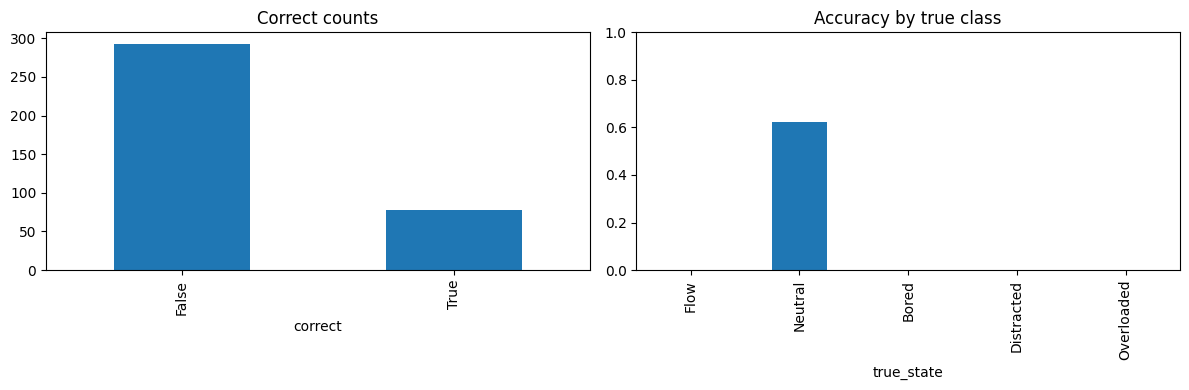

In [6]:
summary = pred_df.groupby(["true_state", "pred_state"]).size().unstack(fill_value=0)
display(summary.reindex(index=STATE_NAMES, columns=STATE_NAMES, fill_value=0))

correct_rate_by_user = pred_df.groupby("user_id")["correct"].agg(["mean", "sum", "count"]).sort_values("mean", ascending=False)
display(correct_rate_by_user)

correct_rate_by_class = pred_df.groupby("true_state")["correct"].agg(["mean", "sum", "count"]).reindex(STATE_NAMES)
display(correct_rate_by_class)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
pred_df["correct"].value_counts().sort_index().plot.bar(ax=axes[0], title="Correct counts")
pred_df.groupby("true_state")["correct"].mean().reindex(STATE_NAMES).plot.bar(ax=axes[1], title="Accuracy by true class")
axes[1].set_ylim(0, 1)
plt.tight_layout()
plt.show()

## 7. Inspect the most confident mistakes

Ces lignes sont utiles pour voir quand le modele est sur de lui mais faux.

In [7]:
cols = [
    "user_id", "session_id", "window_idx", "true_state", "pred_state", "correct",
    "confidence", "margin", "factor_mae",
] + [f"prob_{s}" for s in STATE_NAMES]

mistakes = pred_df[~pred_df["correct"]].sort_values(["confidence", "margin"], ascending=False)
correct = pred_df[pred_df["correct"]].sort_values(["confidence", "margin"], ascending=False)

print("Most confident mistakes")
display(mistakes[cols].head(20))

print("Most confident correct predictions")
display(correct[cols].head(20))

Most confident mistakes


,user_id,session_id,window_idx,true_state,pred_state,correct,confidence,margin,factor_mae,prob_Flow,prob_Neutral,prob_Bored,prob_Distracted,prob_Overloaded
19,dem,session_20260517_113407_c4efba,0,Distracted,Neutral,False,0.446095,0.21573,0.179369,0.106617,0.446095,0.230364,0.092513,0.124412
20,dem,session_20260517_113407_c4efba,1,Distracted,Neutral,False,0.446095,0.21573,0.179369,0.106617,0.446095,0.230364,0.092513,0.124412
21,dem,session_20260517_113407_c4efba,2,Distracted,Neutral,False,0.446095,0.21573,0.179369,0.106617,0.446095,0.230364,0.092513,0.124412
22,dem,session_20260517_113407_c4efba,3,Distracted,Neutral,False,0.446095,0.21573,0.179369,0.106617,0.446095,0.230364,0.092513,0.124412
23,dem,session_20260517_113407_c4efba,4,Distracted,Neutral,False,0.446095,0.21573,0.179369,0.106617,0.446095,0.230364,0.092513,0.124412
24,dem,session_20260517_113407_c4efba,5,Distracted,Neutral,False,0.446095,0.21573,0.179369,0.106617,0.446095,0.230364,0.092513,0.124412
25,dem,session_20260517_113407_c4efba,6,Distracted,Neutral,False,0.446095,0.21573,0.179369,0.106617,0.446095,0.230364,0.092513,0.124412
26,dem,session_20260517_113407_c4efba,7,Distracted,Neutral,False,0.446095,0.21573,0.179369,0.106617,0.446095,0.230364,0.092513,0.124412
27,dem,session_20260517_113407_c4efba,8,Distracted,Neutral,False,0.446095,0.21573,0.179369,0.106617,0.446095,0.230364,0.092513,0.124412
28,dem,session_20260517_113407_c4efba,9,Distracted,Neutral,False,0.446095,0.21573,0.179369,0.106617,0.446095,0.230364,0.092513,0.124412


Most confident correct predictions


,user_id,session_id,window_idx,true_state,pred_state,correct,confidence,margin,factor_mae,prob_Flow,prob_Neutral,prob_Bored,prob_Distracted,prob_Overloaded
16,dem,session_20260517_105229_cb660e,0,Neutral,Neutral,True,0.446095,0.21573,0.130446,0.106617,0.446095,0.230364,0.092513,0.124412
17,dem,session_20260517_105229_cb660e,1,Neutral,Neutral,True,0.446095,0.21573,0.130446,0.106617,0.446095,0.230364,0.092513,0.124412
18,dem,session_20260517_105229_cb660e,2,Neutral,Neutral,True,0.446095,0.21573,0.130446,0.106617,0.446095,0.230364,0.092513,0.124412
35,dem,session_20260517_121410_2c55a5,0,Neutral,Neutral,True,0.446095,0.21573,0.098536,0.106617,0.446095,0.230364,0.092513,0.124412
36,dem,session_20260517_121410_2c55a5,1,Neutral,Neutral,True,0.446095,0.21573,0.098536,0.106617,0.446095,0.230364,0.092513,0.124412
37,dem,session_20260517_121410_2c55a5,2,Neutral,Neutral,True,0.446095,0.21573,0.098536,0.106617,0.446095,0.230364,0.092513,0.124412
38,dem,session_20260517_121410_2c55a5,3,Neutral,Neutral,True,0.446095,0.21573,0.098536,0.106617,0.446095,0.230364,0.092513,0.124412
39,dem,session_20260517_121410_2c55a5,4,Neutral,Neutral,True,0.446095,0.21573,0.098536,0.106617,0.446095,0.230364,0.092513,0.124412
42,dem,session_20260517_121410_2c55a5,7,Neutral,Neutral,True,0.446095,0.21573,0.098536,0.106617,0.446095,0.230364,0.092513,0.124412
43,dem,session_20260517_121410_2c55a5,8,Neutral,Neutral,True,0.446095,0.21573,0.098536,0.106617,0.446095,0.230364,0.092513,0.124412


## 8. Manual filters

Change les variables ci-dessous pour inspecter un user ou une classe precise.

In [8]:
SELECT_USER = None      # example: "dem"
SELECT_TRUE_STATE = None # example: "Distracted"
ONLY_WRONG = False
TOP_N = 50

view = pred_df.copy()
if SELECT_USER is not None:
    view = view[view["user_id"] == SELECT_USER]
if SELECT_TRUE_STATE is not None:
    view = view[view["true_state"] == SELECT_TRUE_STATE]
if ONLY_WRONG:
    view = view[~view["correct"]]

view = view.sort_values(["correct", "confidence"], ascending=[True, False])
display(view[cols].head(TOP_N))

,user_id,session_id,window_idx,true_state,pred_state,correct,confidence,margin,factor_mae,prob_Flow,prob_Neutral,prob_Bored,prob_Distracted,prob_Overloaded
19,dem,session_20260517_113407_c4efba,0,Distracted,Neutral,False,0.446095,0.21573,0.179369,0.106617,0.446095,0.230364,0.092513,0.124412
20,dem,session_20260517_113407_c4efba,1,Distracted,Neutral,False,0.446095,0.21573,0.179369,0.106617,0.446095,0.230364,0.092513,0.124412
21,dem,session_20260517_113407_c4efba,2,Distracted,Neutral,False,0.446095,0.21573,0.179369,0.106617,0.446095,0.230364,0.092513,0.124412
22,dem,session_20260517_113407_c4efba,3,Distracted,Neutral,False,0.446095,0.21573,0.179369,0.106617,0.446095,0.230364,0.092513,0.124412
23,dem,session_20260517_113407_c4efba,4,Distracted,Neutral,False,0.446095,0.21573,0.179369,0.106617,0.446095,0.230364,0.092513,0.124412
24,dem,session_20260517_113407_c4efba,5,Distracted,Neutral,False,0.446095,0.21573,0.179369,0.106617,0.446095,0.230364,0.092513,0.124412
25,dem,session_20260517_113407_c4efba,6,Distracted,Neutral,False,0.446095,0.21573,0.179369,0.106617,0.446095,0.230364,0.092513,0.124412
26,dem,session_20260517_113407_c4efba,7,Distracted,Neutral,False,0.446095,0.21573,0.179369,0.106617,0.446095,0.230364,0.092513,0.124412
27,dem,session_20260517_113407_c4efba,8,Distracted,Neutral,False,0.446095,0.21573,0.179369,0.106617,0.446095,0.230364,0.092513,0.124412
28,dem,session_20260517_113407_c4efba,9,Distracted,Neutral,False,0.446095,0.21573,0.179369,0.106617,0.446095,0.230364,0.092513,0.124412


## 9. Factor regression errors

Les facteurs sont normalises dans `[0,1]`.

,factor,mae,rmse,bias_mean_pred_minus_target
0,mental_demand,0.164613,0.240399,-0.085201
1,temporal_demand,0.267829,0.353623,-0.116327
2,effort,0.166822,0.238380,-0.080881
3,frustration,0.189642,0.250331,-0.094923
4,arousal_proxy,0.210111,0.241377,-0.097747


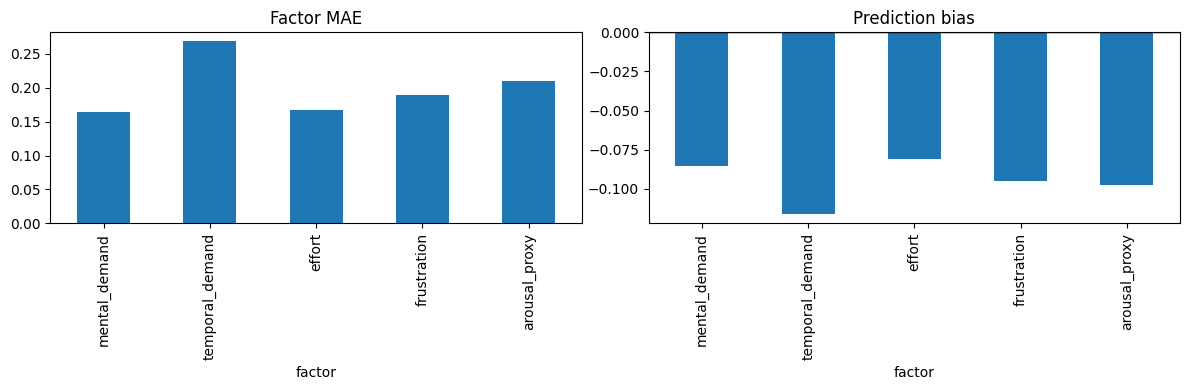

In [9]:
factor_rows = []
for factor in FACTOR_NAMES:
    err = pred_df[f"pred_{factor}"] - pred_df[f"target_{factor}"]
    factor_rows.append({
        "factor": factor,
        "mae": float(np.mean(np.abs(err))),
        "rmse": float(np.sqrt(np.mean(err ** 2))),
        "bias_mean_pred_minus_target": float(np.mean(err)),
    })
factor_error_df = pd.DataFrame(factor_rows)
display(factor_error_df)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
factor_error_df.plot.bar(x="factor", y="mae", ax=axes[0], legend=False, title="Factor MAE")
factor_error_df.plot.bar(x="factor", y="bias_mean_pred_minus_target", ax=axes[1], legend=False, title="Prediction bias")
axes[1].axhline(0, color="black", linewidth=1)
plt.tight_layout()
plt.show()

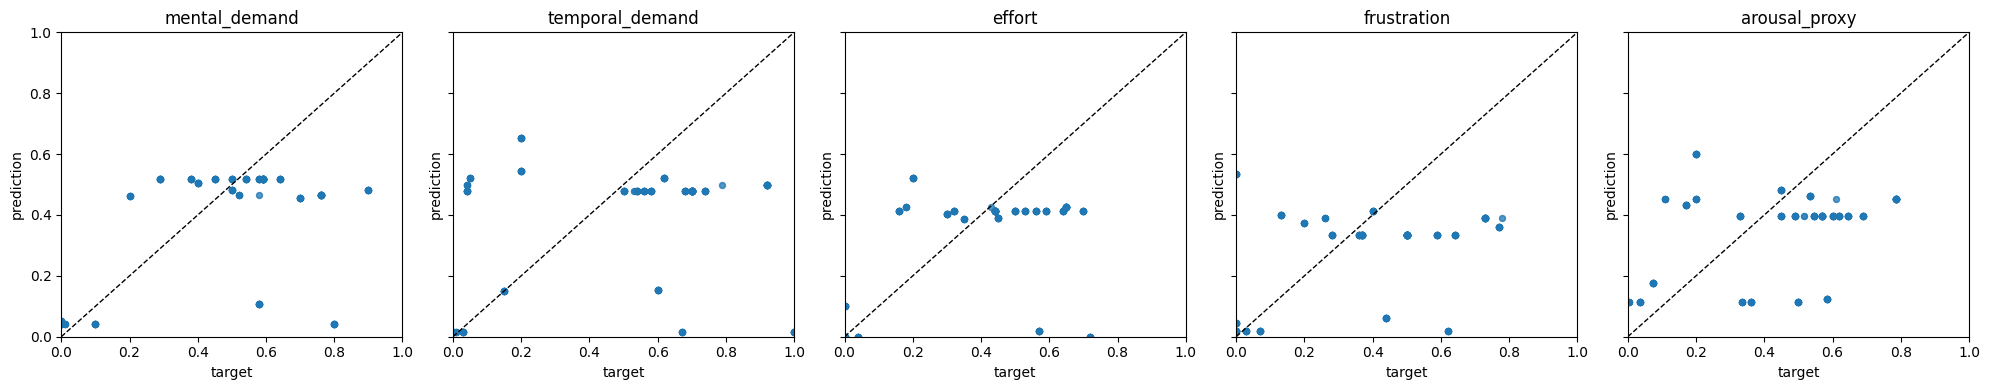

In [10]:
fig, axes = plt.subplots(1, len(FACTOR_NAMES), figsize=(4 * len(FACTOR_NAMES), 4), sharex=True, sharey=True)
for ax, factor in zip(axes, FACTOR_NAMES):
    ax.scatter(pred_df[f"target_{factor}"], pred_df[f"pred_{factor}"], alpha=0.5, s=18)
    ax.plot([0, 1], [0, 1], color="black", linestyle="--", linewidth=1)
    ax.set_title(factor)
    ax.set_xlabel("target")
    ax.set_ylabel("prediction")
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
plt.tight_layout()
plt.show()

## 10. Final single model inspection (optional)

Cette section charge `outputs/switching_predictive/final/best.pt` et predit sur tout le dataset. Ce n'est pas une evaluation unbiased, car ce modele est entraine sur toutes les donnees. C'est utile pour inspecter le comportement du modele final a integrer.

Si PyTorch echoue avec une erreur DLL/pagefile Windows, redemarre le terminal/kernel ou utilise un environnement CPU-only.

In [11]:
TORCH_AVAILABLE = False
try:
    import torch
    from predictive_models.switching.v1_gru_switching import SwitchingGRU
    from scripts.switching.train_switching_predictive import load_training_arrays, prepare_targets, users_from_metadata, INPUT_FLAT_DIM
    TORCH_AVAILABLE = True
    print("torch ok", torch.__version__)
except Exception as exc:
    print("Torch unavailable in this kernel:")
    print(type(exc).__name__, exc)

print("TORCH_AVAILABLE =", TORCH_AVAILABLE)

torch ok 2.5.1+cu121
TORCH_AVAILABLE = True


In [12]:
if TORCH_AVAILABLE and FINAL_CKPT.exists():
    device = torch.device("cpu")
    checkpoint = torch.load(FINAL_CKPT, map_location=device, weights_only=False)
    X, labels, meta, resolved_dir = load_training_arrays(DATA_DIR)
    factors, states = prepare_targets(labels)
    users = users_from_metadata(meta)
    mean = np.asarray(checkpoint["x_mean"], dtype=np.float32)
    std = np.asarray(checkpoint["x_std"], dtype=np.float32)
    Xn = ((X - mean) / std).astype(np.float32)

    model = SwitchingGRU(
        input_flat_dim=int(checkpoint.get("input_flat_dim", INPUT_FLAT_DIM)),
        d_proj=int(checkpoint.get("d_proj", 256)),
        hidden_dim=int(checkpoint.get("hidden_dim", 256)),
    ).to(device)
    model.load_state_dict(checkpoint["model_state_dict"])
    model.eval()

    outputs = []
    with torch.no_grad():
        for start in range(0, Xn.shape[0], 128):
            batch = torch.from_numpy(Xn[start:start + 128]).to(device)
            model.reset_microstate()
            outputs.append(model(batch).cpu().numpy())
    final_out = np.vstack(outputs)
    final_logits = final_out[:, 5:10]
    final_pred = np.argmax(final_logits, axis=1)
    final_correct = final_pred == states

    final_df = pd.DataFrame({
        "user_id": users,
        "session_id": [m.get("session_id") for m in meta],
        "window_idx": [m.get("window_idx") for m in meta],
        "true_label": states,
        "pred_label": final_pred,
        "true_state": [STATE_NAMES[i] for i in states],
        "pred_state": [STATE_NAMES[i] for i in final_pred],
        "correct": final_correct,
    })
    print("Final model in-sample accuracy:", float(final_correct.mean()))
    display(pd.crosstab(final_df["true_state"], final_df["pred_state"]).reindex(index=STATE_NAMES, columns=STATE_NAMES, fill_value=0))
    display(final_df.head())
else:
    print("Final model section skipped. Check TORCH_AVAILABLE and FINAL_CKPT.")

Final model in-sample accuracy: 0.33692722371967654


pred_state,Flow,Neutral,Bored,Distracted,Overloaded
true_state,,,,,
Flow,0,39,0,0,0
Neutral,0,125,0,0,0
Bored,0,65,0,0,0
Distracted,0,111,0,0,0
Overloaded,0,31,0,0,0


,user_id,session_id,window_idx,true_label,pred_label,true_state,pred_state,correct
0,Graja,session_20260515_222916_e5858b,0,2,1,Bored,Neutral,False
1,Graja,session_20260515_222916_e5858b,1,2,1,Bored,Neutral,False
2,Graja,session_20260515_222916_e5858b,2,2,1,Bored,Neutral,False
3,Graja,session_20260515_222916_e5858b,3,2,1,Bored,Neutral,False
4,Graja,session_20260515_222916_e5858b,4,2,1,Bored,Neutral,False


## 11. Baseline comparison

Cette section lit `outputs/switching_predictive/baselines.json` si le nouveau script d'evaluation a ete lance.

Important: `majority_class` est LOSO-safe, car la classe majoritaire est calculee sur le train fold seulement. `global_majority_reference` utilise toute la distribution des labels et sert seulement a expliquer la reference `Neutral = 33.7%`.

In [13]:
BASELINES_JSON = RESULT_DIR / "baselines.json"
if BASELINES_JSON.exists():
    baselines_payload = json.loads(BASELINES_JSON.read_text(encoding="utf-8"))
    baseline_rows = []
    for name, row in baselines_payload.get("baselines", {}).items():
        baseline_rows.append({
            "baseline": name,
            "accuracy": row.get("state_accuracy"),
            "macro_f1": row.get("macro_f1"),
            "mcc": row.get("mcc"),
            "kappa": row.get("cohen_kappa"),
            "majority_class": row.get("majority_class"),
            "note": row.get("note"),
        })
    baseline_df = pd.DataFrame(baseline_rows).sort_values("accuracy", ascending=False)
    display(baseline_df)
else:
    baseline_df = pd.DataFrame()
    print("No baselines.json found. Run scripts/switching/evaluate_switching_predictive.py first.")

,baseline,accuracy,macro_f1,mcc,kappa,majority_class,note
0,global_majority_reference,0.336927,0.100806,0.000000,0.000000,Neutral,Uses the full label distribution for interpret...
2,simple_mlp,0.296496,0.094624,-0.110122,-0.055954,NaN,NaN
1,majority_class,0.210243,0.073759,-0.245224,-0.177867,NaN,NaN
3,stratified_random,0.210243,0.151552,-0.037257,-0.036333,NaN,NaN


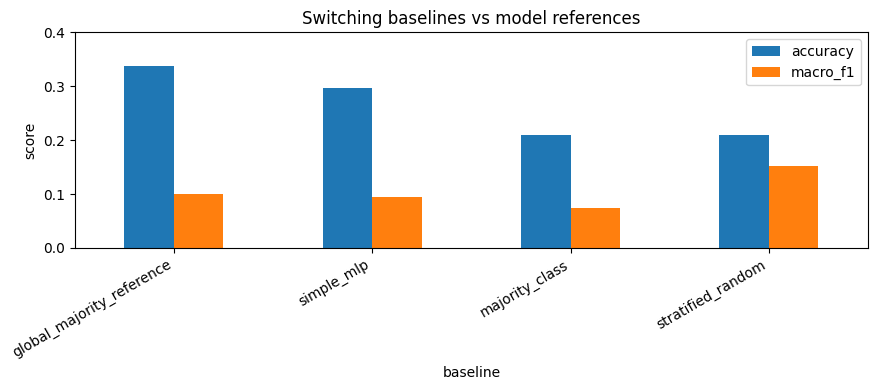

In [14]:
if not baseline_df.empty:
    ax = baseline_df.plot(x="baseline", y=["accuracy", "macro_f1"], kind="bar", figsize=(9, 4), title="Switching baselines vs model references")
    ax.set_ylim(0, max(0.4, float(baseline_df[["accuracy", "macro_f1"]].max().max()) + 0.05))
    ax.set_ylabel("score")
    plt.xticks(rotation=30, ha="right")
    plt.tight_layout()
    plt.show()
else:
    print("No baseline plot available.")

## 12. User label and prediction distributions

Ces fichiers montrent le decalage LOSO par utilisateur et la distribution des predictions du modele.

In [15]:
USER_LABEL_CSV = RESULT_DIR / "user_label_distribution.csv"
USER_PRED_CSV = RESULT_DIR / "user_prediction_distribution.csv"

if USER_LABEL_CSV.exists():
    user_label_df = pd.read_csv(USER_LABEL_CSV)
    display(user_label_df)
else:
    user_label_df = pd.DataFrame()
    print("No user_label_distribution.csv found.")

if USER_PRED_CSV.exists():
    user_pred_df = pd.read_csv(USER_PRED_CSV)
    display(user_pred_df)
else:
    user_pred_df = pd.DataFrame()
    print("No user_prediction_distribution.csv found.")

,user_id,n_samples,n_sessions,Flow,Neutral,Bored,Distracted,Overloaded,majority_class,entropy
0,Graja,11,1,0,0,11,0,0,Bored,0.000000
1,Makki,15,1,0,0,15,0,0,Bored,0.000000
2,amrdroid,16,1,0,16,0,0,0,Neutral,0.000000
3,dem,161,10,16,34,16,95,0,Distracted,0.682576
4,ghoss,15,1,0,15,0,0,0,Neutral,0.000000
5,hffz,41,3,8,2,0,0,31,Overloaded,0.421008
6,ignorant,16,1,0,0,16,0,0,Bored,0.000000
7,ladabos,16,1,0,16,0,0,0,Neutral,0.000000
8,layss,64,5,15,26,7,16,0,Neutral,0.804381
9,mohanned,16,1,0,16,0,0,0,Neutral,0.000000


,user_id,n_samples,pred_Flow,pred_Neutral,pred_Bored,pred_Distracted,pred_Overloaded,state_accuracy,macro_f1,mcc,cohen_kappa
0,amrdroid,16,0,0,0,16,0,0.00000,0.000000,0.0,0.0
1,dem,161,0,161,0,0,0,0.21118,0.069744,0.0,0.0
2,ghoss,15,0,0,0,15,0,0.00000,0.000000,0.0,0.0
3,Graja,11,0,11,0,0,0,0.00000,0.000000,0.0,0.0
4,hffz,41,0,41,0,0,0,0.04878,0.018605,0.0,0.0
5,ignorant,16,0,16,0,0,0,0.00000,0.000000,0.0,0.0
6,ladabos,16,0,0,0,16,0,0.00000,0.000000,0.0,0.0
7,layss,64,0,64,0,0,0,0.40625,0.115556,0.0,0.0
8,Makki,15,0,15,0,0,0,0.00000,0.000000,0.0,0.0
9,mohanned,16,0,16,0,0,0,1.00000,0.200000,0.0,0.0


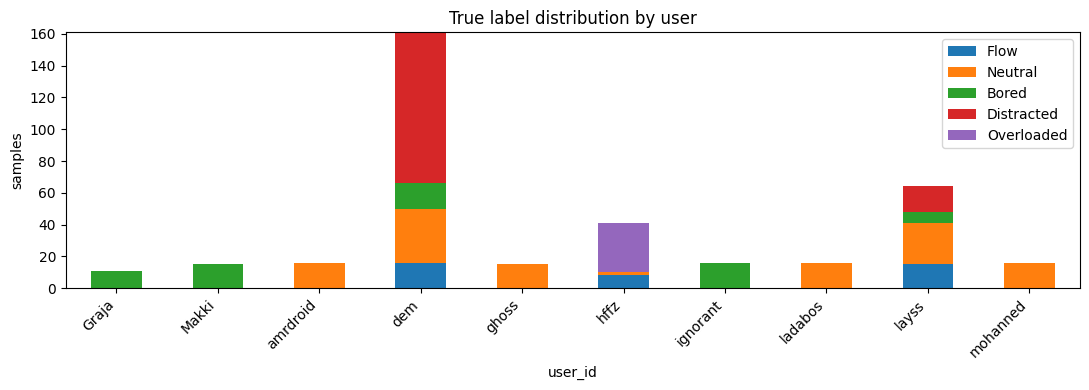

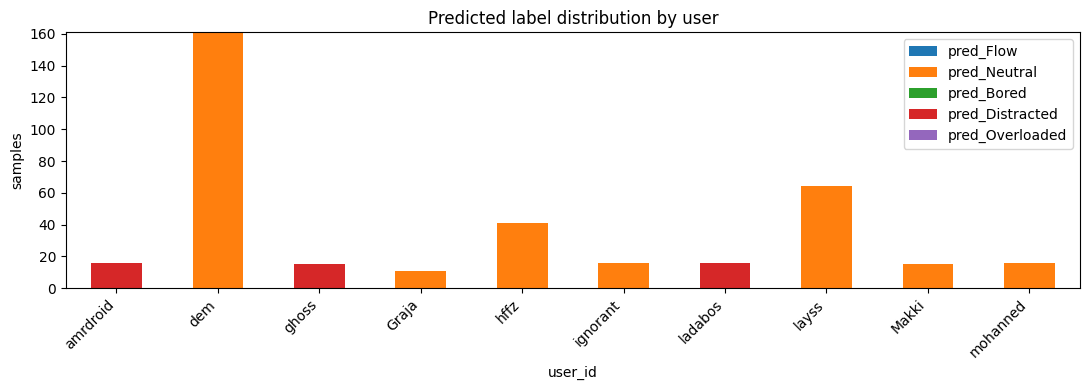

In [16]:
if not user_label_df.empty:
    count_cols = [col for col in STATE_NAMES if col in user_label_df.columns]
    ax = user_label_df.set_index("user_id")[count_cols].plot(kind="bar", stacked=True, figsize=(11, 4), title="True label distribution by user")
    ax.set_ylabel("samples")
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    plt.show()

if not user_pred_df.empty:
    pred_cols = [f"pred_{name}" for name in STATE_NAMES if f"pred_{name}" in user_pred_df.columns]
    ax = user_pred_df.set_index("user_id")[pred_cols].plot(kind="bar", stacked=True, figsize=(11, 4), title="Predicted label distribution by user")
    ax.set_ylabel("samples")
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    plt.show()

## 13. Interpretation checklist

- If LOSO accuracy is low but tiny-overfit passed, the implementation works but generalization/labels are the issue.
- Compare against `majority_class`, not only `global_majority_reference`, when judging LOSO-safe performance.
- If many classes have F1 = 0, inspect class imbalance and heuristic label rules.
- If the model is confidently wrong, inspect high-confidence mistakes above.
- If factor MAE is acceptable but state accuracy is poor, the state derivation heuristic may be too coarse/noisy.
- Use `fold_<user>/best.pt` only for evaluation. Use `final/best.pt` for integration/deployment-style inference.